In [1]:
import pandas as pd


In [4]:
df = pd.read_csv("../data/raw_analyst_ratings.csv", index_col=0)
df.head()

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [5]:
# 1 chech the df info about there count and types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407328 entries, 0 to 1413848
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   headline   1407328 non-null  object
 1   url        1407328 non-null  object
 2   publisher  1407328 non-null  object
 3   date       1407328 non-null  object
 4   stock      1407328 non-null  object
dtypes: object(5)
memory usage: 64.4+ MB


In [6]:
# 2 Handling null Values
print("\n  Null value check (Before Cleaning)")
print(df.isnull().sum())
# we focus on the headline column since it is used for sentiment analysis.
#Drop rows where the headline is null, as we cant analyze empty text

df.dropna(subset=['headline'],inplace=True)
print("\n Null value check (After cleaning)")
print(f"Reamining rows after dropping null headlines:{df.shape[0]}")


  Null value check (Before Cleaning)
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

 Null value check (After cleaning)
Reamining rows after dropping null headlines:1407328


In [7]:
# 3 Duplicate and Consistency checks
# check for duplicate rows across all columns

duplicate_count = df.duplicated().sum()
print(f"\n Total duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    #drop duplicates, keeping the first instance
    df.drop_duplicates(inplace=True)
    print(f"\n rows remaining after dropping duplicates:{df.shape[0]}")
#Ensure the headline column is string type 
df["headline"] = df["headline"].astype(str)


 Total duplicate rows found: 1

 rows remaining after dropping duplicates:1407327


In [8]:
# Converte date column to datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df["date"], format="ISO8601", utc=True)
    print(f"Date type is now {df["date"].dtype}")

    #coverte the index to date
    df.set_index('date',inplace=True)

else:
    print("\nWarning: Date column not found. Skip date conversion")

Date type is now datetime64[ns, UTC]


### ○ Descriptive Statistics:

##### ■ Obtain basic statistics for textual lengths (like headline length).


In [9]:
#Create a new column for headline length and count
df = df.assign(
    headline_length=df["headline"].astype(str).str.len(),
    headline_word_count=df["headline"].astype(str).str.split().str.len()
)

In [10]:
df[['headline_length','headline_word_count']].describe()

,headline_length,headline_word_count
count,1.407327e+06,1.407327e+06
mean,7.312054e+01,1.141671e+01
std,4.073532e+01,6.352998e+00
min,3.000000e+00,1.000000e+00
25%,4.700000e+01,7.000000e+00
50%,6.400000e+01,1.000000e+01
75%,8.700000e+01,1.300000e+01
max,5.120000e+02,7.700000e+01


### 📝 Summary of Headline Length Statistics

We computed basic statistics for two metrics:
- **`headline_length`** — number of characters in the headline  
- **`headline_word_count`** — number of words in the headline  

The results are summarized below:

#### 📌 Key Observations

- The dataset contains **1.4 million headlines**.
- **Average headline length** is about **73 characters**, with a typical range from **47 to 87 characters** (25th–75th percentile).
- **Word count averages** around **11 words**, with most headlines falling between **7 and 13 words**.
- The **shortest headlines** are extremely brief (3 characters or 1 word).
- The **longest headline** reaches **512 characters** and **77 words**, indicating the presence of unusually long titles.


##### ■ Count the number of articles per publisher to identify which publishers are most active.


In [11]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()
publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186978
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

### Most active Publishers
| Publisher           | Article Count |
|---------------------|---------------|
| Paul Quintaro       | 228,373       |
| Lisa Levin          | 186,978       |
| Benzinga Newsdesk   | 150,484       |

### 🏆 Most Active Publisher
**Paul Quintaro** is the most active publisher with **228,373 articles**.


#### ■ Analyze the publication dates to see trends over time, such as increased news frequency on particular days or during specific events.


In [13]:
df['day'] = df.index.day
# This shows daily publication frequency:
daily_counts = df.index.normalize().value_counts().sort_index()
print(daily_counts)


date
2009-02-14 00:00:00+00:00      1
2009-04-27 00:00:00+00:00      2
2009-04-29 00:00:00+00:00      1
2009-05-22 00:00:00+00:00      1
2009-05-27 00:00:00+00:00      6
                            ... 
2020-06-07 00:00:00+00:00     25
2020-06-08 00:00:00+00:00    765
2020-06-09 00:00:00+00:00    803
2020-06-10 00:00:00+00:00    807
2020-06-11 00:00:00+00:00    544
Name: count, Length: 3955, dtype: int64


##### Visualize trends

<Axes: title={'center': 'Articles per Day'}, xlabel='date'>

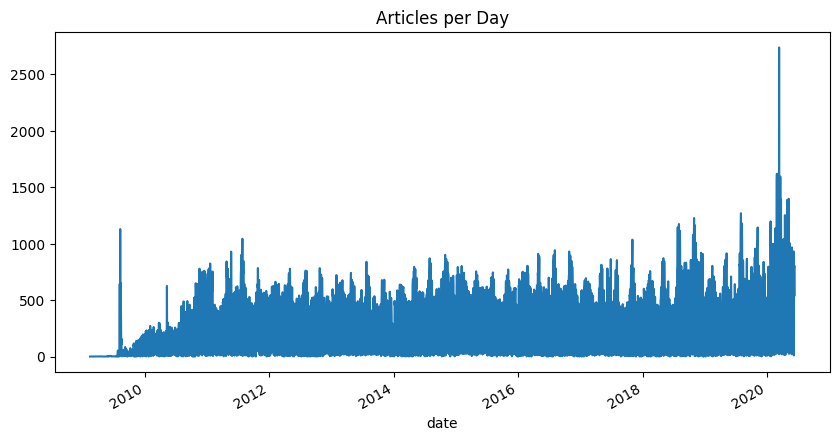

In [14]:
daily_counts.plot(kind='line', figsize=(10,5), title='Articles per Day')

## 📅 Most Active Publication Date

- **Date:** 2020-06-11  
- **Total Articles Published:** 544  

This day shows a **significant spike** in publishing activity compared to other dates in your dataset.


## ○ Text Analysis(Topic Modeling):